In [15]:
   %load_ext autoreload
   %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:

from ErrP_decoder.data_io import select_eeg_files, load_selected_files

file_paths = select_eeg_files()

datasets = load_selected_files(file_paths)

for ds in datasets:
    print("Data shape:", ds.data.shape)
    print("Info:", ds.info)

Extracting EDF parameters from /Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM rotation/ErrP_decoder/data/subject3/subject101_1.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
AF3, AF4, F3, F1, FZ, F2, F4, FC3, FC1, FCZ, FC2, FC4, C3, C1, CZ, C2, C4, CP3, CP1, CPZ, CP2, CP4, P3, P1, PZ, P2, P4, PO3, POZ, PO4, O1, O2, sens7, sens8, sens9
Creating raw.info structure...
Reading 0 ... 272383  =      0.000 ...   531.998 secs...
Extracting EDF parameters from /Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM rotation/ErrP_decoder/data/subject3/subject101_2.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
AF3, AF4, F3, F1, FZ, F2, F4, FC3, FC1, FCZ, FC2, FC4, C3, C1, CZ, C2, C4, CP3, CP1, CPZ, CP2, CP4, P3, P1, PZ, P2, P4, PO3, POZ, PO4, O1, O2, sens7, sen

In [17]:
from ErrP_decoder.data_io import set_params
for ds in datasets:
    cfg = set_params(ds.info,config_path="../configs/default.yaml")

In [18]:
from ErrP_decoder.data_io import preprocess_dataset
for ds in datasets:
    ds = preprocess_dataset(ds, cfg)

for ds in datasets:
    neu = sum(ds.trig['typ'] == 0)
    pos = sum(ds.trig['typ'] == 1)
    neg = sum(ds.trig['typ'] == 2)
    print(neu)
    print(pos)
    print(neg)
    


167
33
0
170
31
0
167
35
0
161
39
0
164
36
0


In [19]:
from ErrP_decoder.data_io import bandpass_filter
from ErrP_decoder.plots import plot_eeg_interactive

for ds in datasets:
    filtered_eeg = bandpass_filter(ds.eeg,cfg)
    plot_eeg_interactive(filtered_eeg, cfg)
    ds.eeg_filt = filtered_eeg

interactive(children=(IntSlider(value=0, continuous_update=False, description='Page', max=267264, step=5120), …

interactive(children=(IntSlider(value=0, continuous_update=False, description='Page', max=249856, step=5120), …

interactive(children=(IntSlider(value=0, continuous_update=False, description='Page', max=237056, step=5120), …

interactive(children=(IntSlider(value=0, continuous_update=False, description='Page', max=231936, step=5120), …

interactive(children=(IntSlider(value=0, continuous_update=False, description='Page', max=231424, step=5120), …

In [20]:
from ErrP_decoder.data_io import epoch_data
for ds in datasets:
    ds.epochs, ds.epoch_labels = epoch_data(ds.eeg_filt,cfg,ds.trig)
    ds.epochs = ds.epochs.transpose(1, 2, 0)
    # epochs (768,32,200)
    # epoch_labels (200,)

In [21]:
import numpy as np

all_epochs = []
all_labels = []
for ds in datasets:
    all_epochs.append(ds.epochs)
    all_labels.append(ds.epoch_labels)
# Concatenate along the epochs axis (axis=2 for epochs, axis=0 for labels)
epochs_combined = np.concatenate(all_epochs, axis=2)
labels_combined = np.concatenate(all_labels, axis=0)

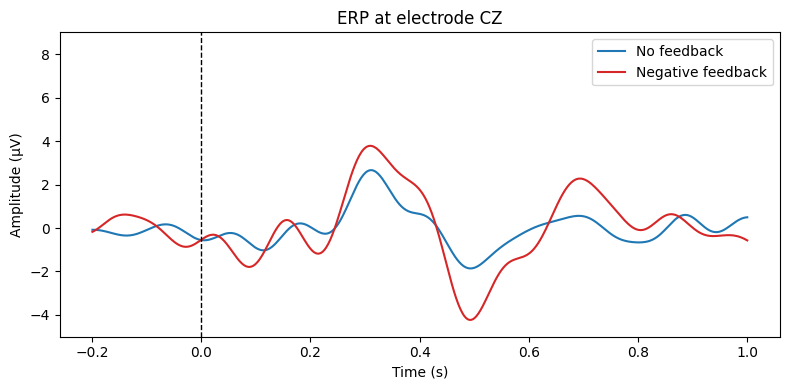

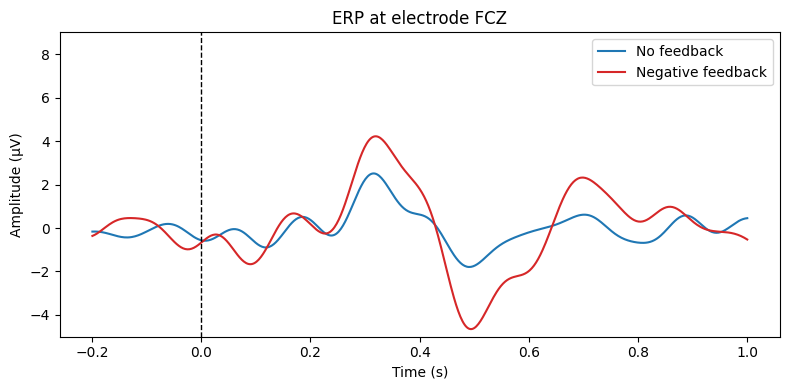

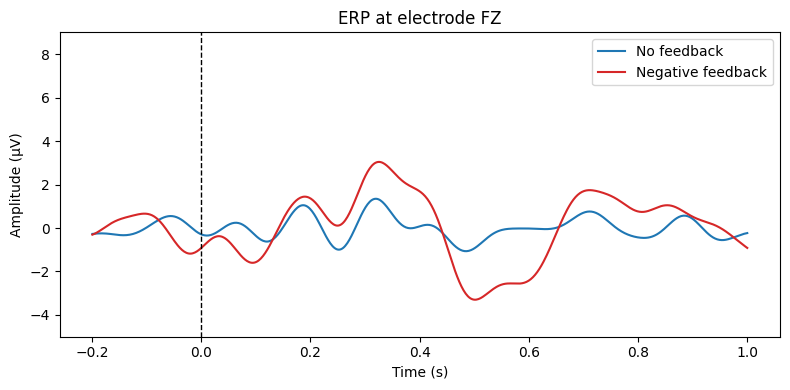

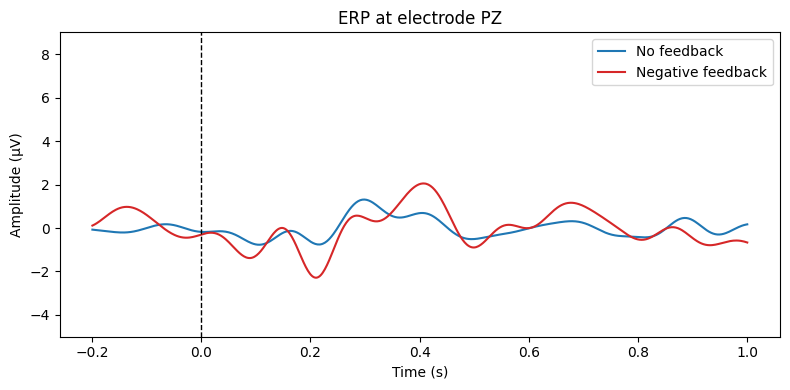

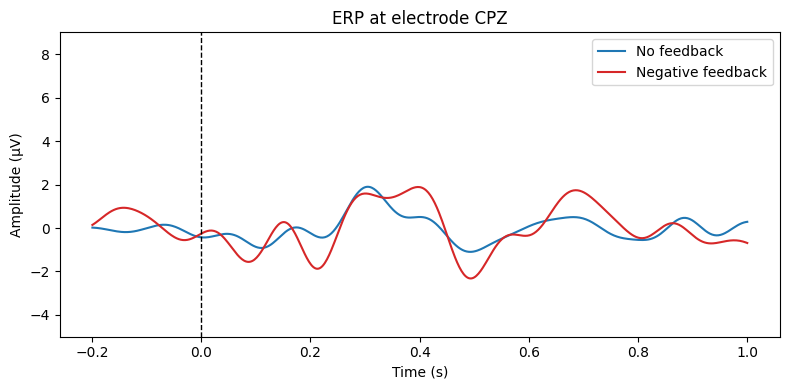

In [22]:
from ErrP_decoder.plots import plot_erp
plot_erp(epochs_combined, labels_combined, cfg, 'CZ')
plot_erp(epochs_combined, labels_combined, cfg, 'FCZ')
plot_erp(epochs_combined, labels_combined, cfg, 'FZ')
plot_erp(epochs_combined, labels_combined, cfg, 'PZ')
plot_erp(epochs_combined, labels_combined, cfg, 'CPZ')

In [23]:
from ErrP_decoder.data_io import balance_runs
for ds in datasets:
    ds.epochs_balanced, ds.epoch_labels_balanced = balance_runs(ds.epochs,ds.epoch_labels)

In [24]:
for ds in datasets:
    print(ds.epochs_balanced.shape)


(768, 32, 66)
(768, 32, 62)
(768, 32, 70)
(768, 32, 78)
(768, 32, 72)


In [25]:

all_epochs = []
all_labels = []
run_labels = []

for i, ds in enumerate(datasets):
    all_epochs.append(ds.epochs_balanced)              # shape: (samples, channels, trials)
    all_labels.append(ds.epoch_labels_balanced)        # shape: (trials,)

    n_trials = ds.epoch_labels_balanced.shape[0]
    run_labels.append(np.full(n_trials, i))            # start from 0

training_epochs   = np.concatenate(all_epochs, axis=2)   # shape: (768,32,306)
training_labels = np.concatenate(all_labels, axis=0)   # shape: (306,)
training_run_labels = np.concatenate(run_labels, axis=0)   # shape: (306,)
train_data = {
    'data' : training_epochs,
    'labels' : training_labels,
    'run' : training_run_labels
}



In [26]:
all_epochs = []
all_labels = []
run_labels = []

for i, ds in enumerate(datasets):
    all_epochs.append(ds.epochs)              # shape: (samples, channels, trials)
    all_labels.append(ds.epoch_labels)        # shape: (trials,)

    n_trials = ds.epoch_labels.shape[0]
    run_labels.append(np.full(n_trials, i))   # start from 0

test_epochs   = np.concatenate(all_epochs, axis=2)   # shape: (768,32,1000)
test_labels = np.concatenate(all_labels, axis=0)   # shape: (1000,)
test_run_labels = np.concatenate(run_labels, axis=0)   # shape: (1000,)
test_data = {
    'data' : test_epochs,
    'labels' : test_labels,
    'run' : test_run_labels
}

In [27]:
from ErrP_decoder.modeling import leave_one_run_out_cv
posteriors = leave_one_run_out_cv(train_data, test_data, cfg)

In [28]:
from ErrP_decoder.evaluation import evaluate_classifier
evaluate_classifier(test_data['labels'], posteriors)

== Synchronous Classification == 
AUC score : 0.56   Threshold: 0.50
Confusion Matrix:
[[464 365]
 [ 81  93]]
TNR: 0.56   TPR: 0.53


{'fpr': array([0.        , 0.00120627, 0.00844391, 0.00844391, 0.01085645,
        0.01085645, 0.013269  , 0.013269  , 0.01568154, 0.01568154,
        0.02171291, 0.02171291, 0.02291918, 0.02291918, 0.02533172,
        0.02533172, 0.03015682, 0.03015682, 0.03618818, 0.03618818,
        0.03739445, 0.03739445, 0.03860072, 0.03860072, 0.039807  ,
        0.039807  , 0.06272618, 0.06272618, 0.06755127, 0.06755127,
        0.07599517, 0.07599517, 0.07720145, 0.07720145, 0.07840772,
        0.07840772, 0.08926417, 0.08926417, 0.09288299, 0.09288299,
        0.10615199, 0.10615199, 0.11097708, 0.11097708, 0.11338963,
        0.11338963, 0.11821472, 0.11821472, 0.13268999, 0.13268999,
        0.13751508, 0.13751508, 0.1411339 , 0.1411339 , 0.14475271,
        0.14475271, 0.1761158 , 0.1761158 , 0.18576598, 0.18576598,
        0.1893848 , 0.1893848 , 0.19662244, 0.19662244, 0.20868516,
        0.20868516, 0.2291918 , 0.2291918 , 0.23642943, 0.23642943,
        0.23884198, 0.23884198, 0.2448733

: 

In [ ]:
from ErrP_decoder.evaluation import plot_posteriors_by_class
plot_posteriors_by_class(test_data['labels'], posteriors, 
                         class_names=['No Feedback', 'Negative Feedback'], bins=20)

                            COMPUTE DECODER FUNCTIONS TESTING BELOW

In [29]:
from ErrP_decoder.modeling import compute_decoder

decoder = decoder = compute_decoder(training_data, training_labels, cfg)

In [12]:
from ErrP_decoder.modeling import get_cca_spatialfilter

spatial_filter = get_cca_spatialfilter(training_data, training_labels, 
                                       n_components=cfg['spatial_filter']['n_comp']) # shape (32,2)



In [13]:

from ErrP_decoder.modeling import apply_spatial_filter
filtered_data = apply_spatial_filter(training_data, spatial_filter) # shape: (samples, n_components, trials)

In [14]:
from ErrP_decoder.modeling import resample_epochs
resampled = resample_epochs(filtered_data,cfg) # shape (20, 3, 306)


In [26]:
n_samples, n_comp, n_trials = resampled.shape
X = resampled.reshape(n_samples * n_comp, n_trials).T # shape: (samples, features) e.g. (306,60)
y = training_labels # shape: (samples, ) e.g. (306,)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

print("LDA coefficients shape:", lda.coef_.shape)       # (n_classes-1, n_features)
print("LDA intercepts shape:", lda.intercept_.shape)